# Mobile Price Classification

| Column Name | Description |
|-------------|-------------|
| battery_power | Total energy a battery can store in one time measured in mAh |
| blue | Has bluetooth or not |
| clock_speed | Speed at which microprocessor executes instructions |
| dual_sim | Has dual sim support or not |
| fc | Front Camera mega pixels |
| four_g | Has 4G or not |
| int_memory | Internal Memory in Gigabytes |
| m_dep | Mobile Depth in cm |
| mobile_wt | Weight of mobile phone |
| n_cores | Number of cores of processor |
| pc | Primary Camera mega pixels |
| px_height | Pixel Resolution Height |
| px_width | Pixel Resolution Width |
| ram | Random Access Memory in Megabytes |
| sc_h | Screen Height of mobile in cm |
| sc_w | Screen Width of mobile in cm |
| talk_time | Longest time that a single battery charge will last when you are |
| three_g | Has 3G or not |
| touch_screen | Has touch screen or not |
| wifi | Has wifi or not |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings("ignore")

In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [4]:
train

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [5]:
test

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,...,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,18,749,810,1773,15,8,7,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,1700,1,1.9,0,0,1,54,0.5,170,...,17,644,913,2121,14,8,15,1,1,0
996,997,609,0,1.8,1,0,0,13,0.9,186,...,2,1152,1632,1933,8,1,19,0,1,1
997,998,1185,0,1.4,0,1,1,8,0.5,80,...,12,477,825,1223,5,0,14,1,0,0
998,999,1533,1,0.5,1,0,0,50,0.4,171,...,12,38,832,2509,15,11,6,0,1,0


In [6]:
train.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

## Basic Exploratory Data Analysis(EDA)

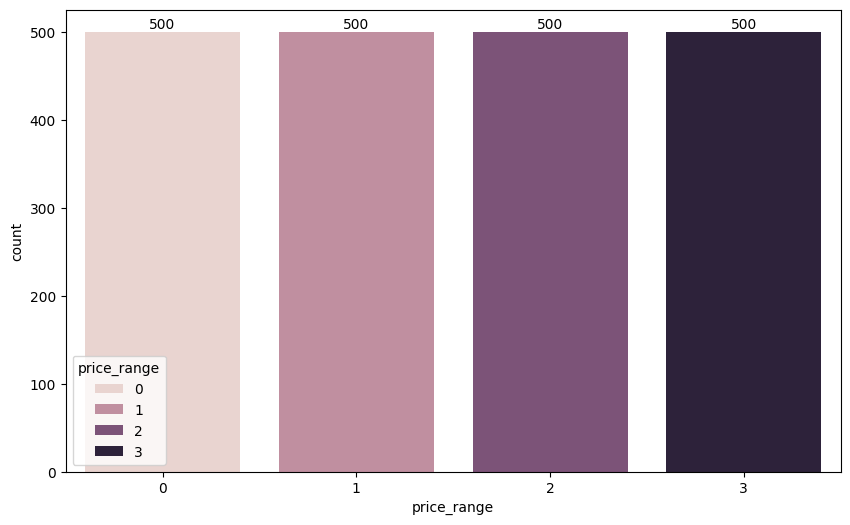

In [9]:
plt.figure(figsize= (10, 6))

ax = sns.countplot(
    data= train,
    x = "price_range",
    hue= "price_range"
)

for container in ax.containers:
    ax.bar_label(container)

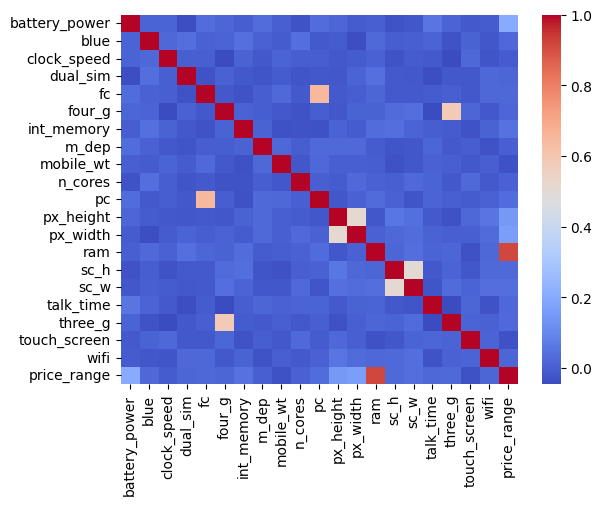

In [10]:
corr = train.corr()

sns.heatmap(corr, cmap= "coolwarm")
plt.show()

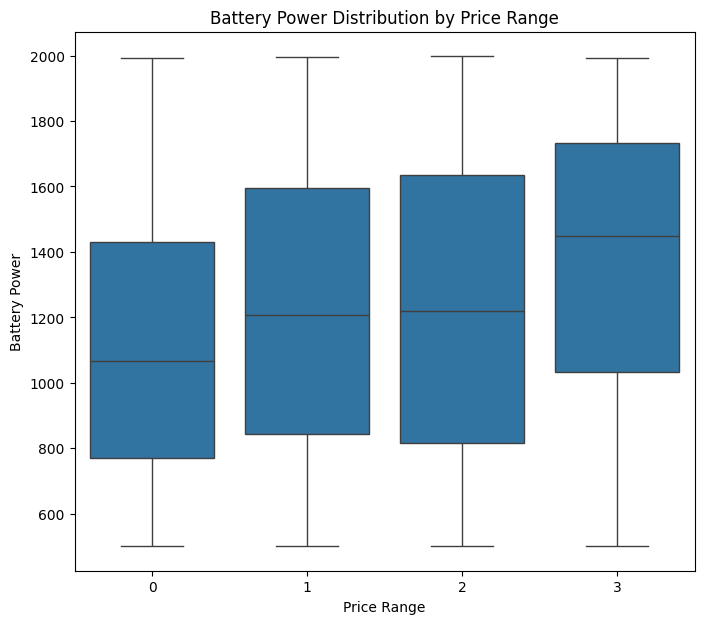

In [11]:
plt.figure(figsize= (8, 7))

ax = sns.boxplot(
    data= train,
    y= "battery_power",
    x= "price_range"
)

ax.set_title("Battery Power Distribution by Price Range")
ax.set_xlabel("Price Range")
ax.set_ylabel("Battery Power")

plt.show()

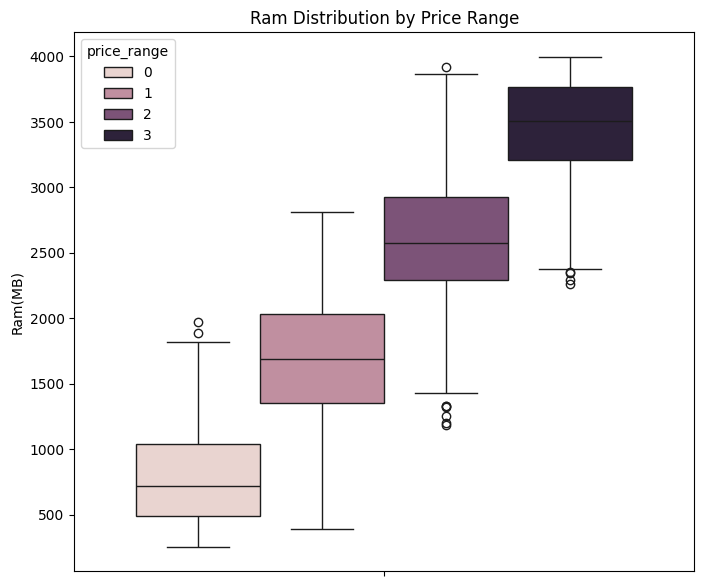

In [12]:
plt.figure(figsize= (8, 7))

ax = sns.boxplot(
    data= train,
    y= "ram",
    hue= "price_range"
)

ax.set_title("Ram Distribution by Price Range")
ax.set_ylabel("Ram(MB)")

plt.show()

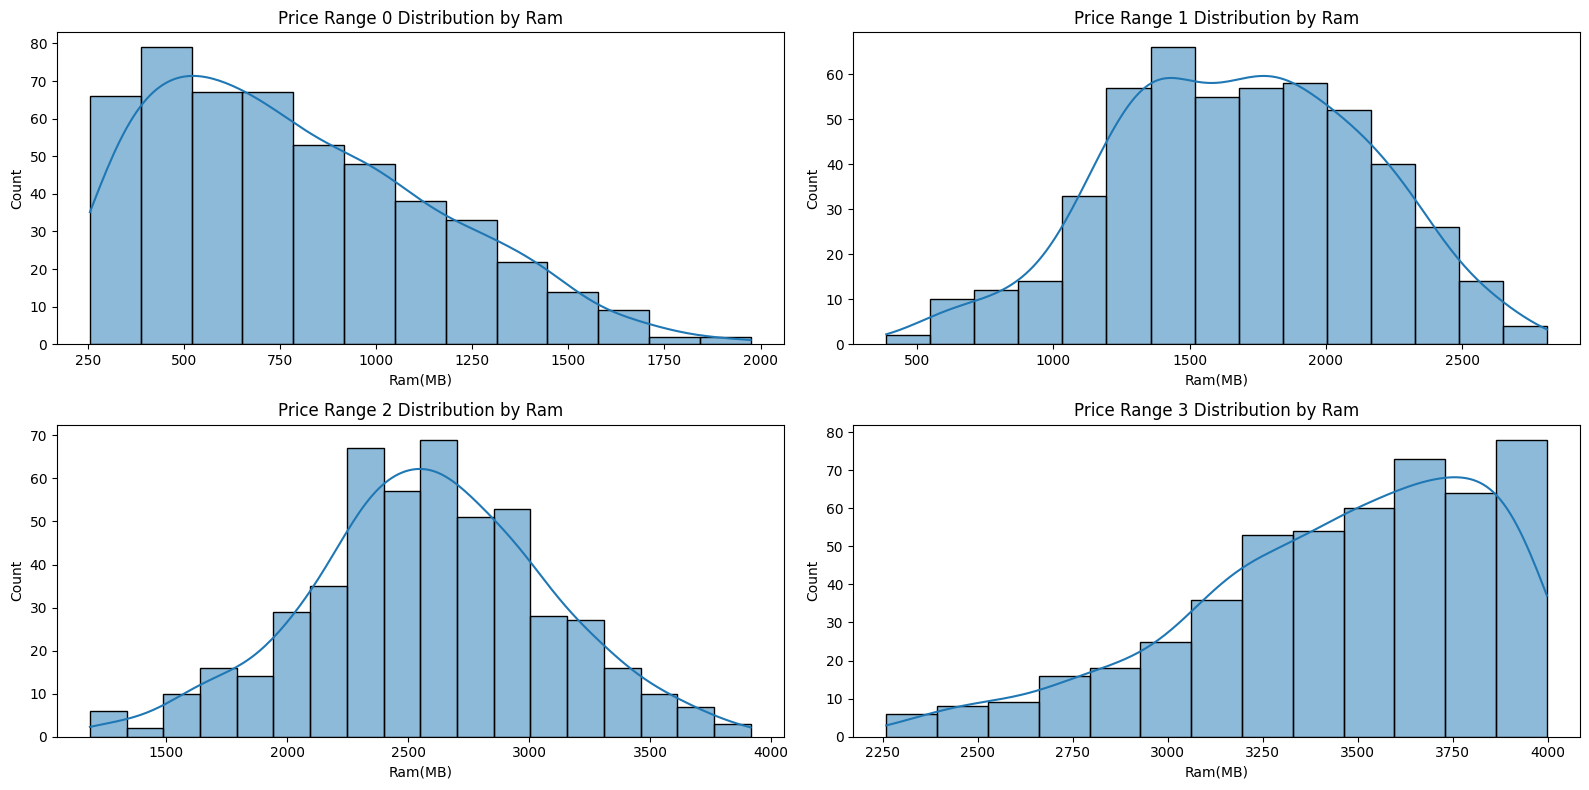

In [13]:
values = sorted(train["price_range"].unique())

fig, ax = plt.subplots(2, 2, figsize = (16, 8))
ax = ax.ravel()

for index, value in enumerate(values):
    axis = sns.histplot(
        data= train[train["price_range"] == value],
        x= "ram",
        kde= True,
        ax= ax[index]
    )
    axis.set_title(f"Price Range {value} Distribution by Ram")
    axis.set_xlabel("Ram(MB)")


plt.tight_layout()
plt.show()

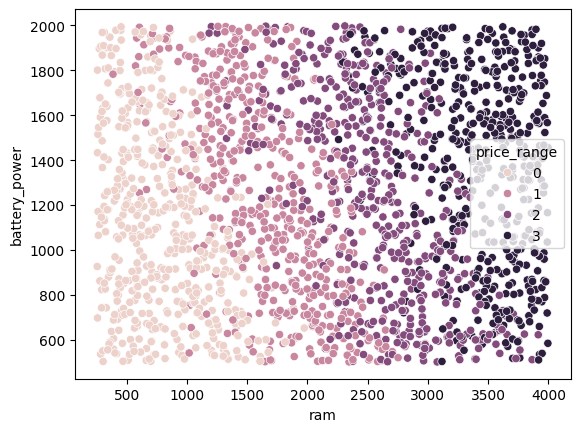

In [14]:
sns.scatterplot(
    data= train,
    x= "ram",
    y= "battery_power",
    hue= "price_range"
)

plt.show()

## Preprocessing

In [15]:
test.drop("id", axis= 1, inplace= True)

In [16]:
train["reslution"] = train["px_height"] * train["px_width"]
test["reslution"] = test["px_height"] * test["px_width"]

## Training

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X = train.drop("price_range", axis= 1)
y = train["price_range"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Logistic Regression

In [22]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV

In [23]:
logistic = LogisticRegression()

pipeline = Pipeline([
    ("scaler", scaler),
    ("logistic", logistic)
])
pipeline.fit(X_train, y_train)

score = pipeline.score(X_test, y_test)
print(f"Logistic Regression : {score}")

predicts = pipeline.predict(X_test)

print(f"Classification Report :\n{classification_report(y_test, predicts)}\n")
print(f"Confusion Matrix\n{confusion_matrix(y_test, predicts)}")

Logistic Regression : 0.975
Classification Report :
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       105
           1       0.95      0.99      0.97        91
           2       0.99      0.95      0.97        92
           3       0.97      0.99      0.98       112

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.98      0.97      0.97       400


Confusion Matrix
[[102   3   0   0]
 [  1  90   0   0]
 [  0   2  87   3]
 [  0   0   1 111]]


In [24]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [25]:
logistic = LogisticRegression()
cv = StratifiedKFold()

In [ ]:
logistic = LogisticRegression()

pipeline = Pipeline([
    ("scaler", scaler),
    ("logistic", logistic)
])

penalty = ["l1", "l2", "elasticnet"]
C = [0.01, 0.1, 10, 100]
solver = ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
multi_class = ['auto', 'ovr', 'multinomial']

params = dict(
    logistic__penalty = penalty,
    logistic__C = C,
    logistic__solver = solver,
    logistic__multi_class = multi_class
)

grid = GridSearchCV(
    estimator= pipeline,
    param_grid= params,
    cv = cv,
    n_jobs= -1
)

grid.fit(X_train, y_train)

predicts = grid.predict(X_test)

score = accuracy_score(y_test, predicts)
print(f"Tuned Logistic Regression : {score}")
print(f"Classification Report :\n{classification_report(y_test, predicts)}\n")
print(f"Confusion Matrix\n{confusion_matrix(y_test, predicts)}")

Tuned Logistic Regression : 0.9675
Classification Report :
              precision    recall  f1-score   support

           0       0.99      0.93      0.96       105
           1       0.93      0.99      0.96        91
           2       0.98      0.97      0.97        92
           3       0.97      0.98      0.98       112

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400


Confusion Matrix
[[ 98   7   0   0]
 [  1  90   0   0]
 [  0   0  89   3]
 [  0   0   2 110]]


## Support Vector Classifier

In [29]:
from sklearn.svm import SVC

In [30]:
svc = SVC()

pipeline = Pipeline([
    ("scaler", scaler),
    ("svc", svc)
])
pipeline.fit(X_train, y_train)

score = pipeline.score(X_test, y_test)
print(f"Support Vector Classifier : {score}")

predicts = pipeline.predict(X_test)

print(f"Classification Report :\n{classification_report(y_test, predicts)}\n")
print(f"Confusion Matrix\n{confusion_matrix(y_test, predicts)}")

Support Vector Classifier : 0.89
Classification Report :
              precision    recall  f1-score   support

           0       0.95      0.92      0.94       105
           1       0.79      0.88      0.83        91
           2       0.84      0.82      0.83        92
           3       0.96      0.93      0.95       112

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400


Confusion Matrix
[[ 97   8   0   0]
 [  5  80   6   0]
 [  0  13  75   4]
 [  0   0   8 104]]


In [33]:
svc = SVC()
cv = StratifiedKFold()

pipeline = Pipeline([
    ("scaler", scaler),
    ("svc", svc)
])

kernel = ["linear", "poly", "rbf", "sigmoid"]
C = [0.01, 0.1, 10, 100]
gamma = ["scale", "auto"]

params = dict(
    svc__kernel = kernel,
    svc__C = C,
    svc__gamma = gamma
)

grid = GridSearchCV(
    estimator= pipeline,
    param_grid= params,
    cv = cv,
    n_jobs= -1
)

grid.fit(X_train, y_train)

predicts = grid.predict(X_test)

score = accuracy_score(y_test, predicts)
print(f"Tuned SVC : {score}")
print(f"Classification Report :\n{classification_report(y_test, predicts)}\n")
print(f"Confusion Matrix\n{confusion_matrix(y_test, predicts)}")

Tuned SVC : 0.965
Classification Report :
              precision    recall  f1-score   support

           0       1.00      0.95      0.98       105
           1       0.91      1.00      0.95        91
           2       0.98      0.92      0.95        92
           3       0.97      0.98      0.98       112

    accuracy                           0.96       400
   macro avg       0.97      0.96      0.96       400
weighted avg       0.97      0.96      0.97       400


Confusion Matrix
[[100   5   0   0]
 [  0  91   0   0]
 [  0   4  85   3]
 [  0   0   2 110]]


## K-Nearest Neighbors

In [34]:
from sklearn.neighbors import KNeighborsClassifier

In [36]:
classifier = KNeighborsClassifier()

pipeline = Pipeline([
    ("scaler", scaler),
    ("classifier", classifier)
])
pipeline.fit(X_train, y_train)

score = pipeline.score(X_test, y_test)
print(f"KNC : {score}")

predicts = pipeline.predict(X_test)

print(f"Classification Report :\n{classification_report(y_test, predicts)}\n")
print(f"Confusion Matrix\n{confusion_matrix(y_test, predicts)}")

KNC : 0.53
Classification Report :
              precision    recall  f1-score   support

           0       0.69      0.69      0.69       105
           1       0.36      0.46      0.40        91
           2       0.35      0.38      0.36        92
           3       0.81      0.56      0.66       112

    accuracy                           0.53       400
   macro avg       0.55      0.52      0.53       400
weighted avg       0.57      0.53      0.54       400


Confusion Matrix
[[72 28  5  0]
 [23 42 23  3]
 [ 8 37 35 12]
 [ 2 10 37 63]]


In [38]:
classifier = KNeighborsClassifier()
cv = StratifiedKFold()

pipeline = Pipeline([
    ("scaler", scaler),
    ("classifier", classifier)
])

n_neighbors = [3, 5, 8, 12, 15, 20]
weights = ['uniform', 'distance']
algorithm = ["kd_tree", "ball_tree"]
p = [1, 2]

params = dict(
    classifier__n_neighbors = n_neighbors,
    classifier__weights = weights,
    classifier__algorithm = algorithm,
    classifier__p = p
)

grid = GridSearchCV(
    estimator= pipeline,
    param_grid= params,
    cv = cv,
    n_jobs= -1
)

grid.fit(X_train, y_train)

predicts = grid.predict(X_test)

score = accuracy_score(y_test, predicts)
print(f"Tuned KNC : {score}")
print(f"Classification Report :\n{classification_report(y_test, predicts)}\n")
print(f"Confusion Matrix\n{confusion_matrix(y_test, predicts)}")

Tuned KNC : 0.645
Classification Report :
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       105
           1       0.47      0.49      0.48        91
           2       0.49      0.55      0.52        92
           3       0.83      0.72      0.77       112

    accuracy                           0.65       400
   macro avg       0.64      0.64      0.64       400
weighted avg       0.66      0.65      0.65       400


Confusion Matrix
[[81 23  1  0]
 [20 45 25  1]
 [ 1 24 51 16]
 [ 1  3 27 81]]
